# Supplementary Materials PDF: Compile All Extended Results into LaTeX Appendices

This notebook demonstrates the evaluation pipeline that compiles supplementary materials for a NeurIPS paper on **Critical Slowing Down (CSD) Indicators for LLM Capability Boundary Detection**.

**What it does:**
- Loads 9 data sources (4 dependent experiments + 5 evaluation files)
- Generates 8 appendices (A-H) covering CSD profiles, ablation studies, routing simulations, cross-task transfer, sample-size sensitivity, negative controls, and syllogistic analysis
- Produces matplotlib figures and LaTeX tables
- Computes completeness metrics

The demo uses a curated mini dataset to illustrate the full pipeline.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loguru import logger

# Logging
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter7_supplementary_m/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
logger.info(f"Loaded {len(data)} data sources: {list(data.keys())}")

10:51:14|INFO   |Loaded 9 data sources: ['dep1_arithmetic', 'dep2_graph_coloring', 'dep3_classifier', 'dep4_syllogistic', 'eval_ablation', 'eval_routing', 'eval_transfer', 'eval_sc_criteria', 'eval_prospective']


In [5]:
# ---- CONFIG ----
# Number of table rows to display per appendix (minimum for demo)
MAX_TABLE_ROWS = 30
# Figure DPI (lower = faster)
FIGURE_DPI = 100
# Figure size multiplier
FIG_SCALE = 1.0

## Helper Functions

LaTeX-safe string escaping and model name shortening utilities used across all appendix builders.

In [6]:
def tex_escape(s: str) -> str:
    """Escape special LaTeX characters."""
    replacements = {
        "&": r"\&", "%": r"\%", "$": r"\$", "#": r"\#",
        "_": r"\_", "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    return s


def short_model(m: str) -> str:
    """Shorten model name for tables."""
    return m.split("/")[-1] if "/" in m else m

## Appendix A: Per-Model-Task CSD Profiles

Builds per-model-task CSD indicator profiles for sharp-boundary pairs from arithmetic and graph coloring experiments.

In [7]:
def build_appendix_a(data: dict) -> tuple:
    """Build per-model-task CSD indicator profiles for sharp-boundary pairs."""
    logger.info("Building Appendix A: Per-model-task CSD profiles")
    pairs_reported = 0
    profile_data = []

    for dep_key, task_name in [("dep1_arithmetic", "arithmetic"), ("dep2_graph_coloring", "graph coloring")]:
        dep = data.get(dep_key)
        if dep is None:
            continue
        for ds in dep.get("datasets", []):
            examples = ds.get("examples", [])
            if not examples:
                continue
            first_ex = examples[0]
            model = first_ex.get("metadata_model", "unknown")
            d_star = first_ex.get("metadata_d_star")
            if d_star is None:
                meta = dep.get("metadata", {})
                analysis = meta.get("analysis", {})
                for m_info in analysis.get("models", []):
                    if m_info.get("model") == model:
                        d_star = m_info.get("d_star")
                        break

            level_data = {}
            for ex in examples:
                diff = ex.get("metadata_difficulty_level", ex.get("metadata_difficulty"))
                if diff is None:
                    continue
                if diff not in level_data:
                    level_data[diff] = {"acc": [], "var": [], "dip": [], "sil": [], "bc": [], "dis": []}
                acc_val = ex.get("predict_accuracy")
                var_val = ex.get("predict_csd_variance", ex.get("metadata_csd_embedding_variance"))
                dip_val = ex.get("predict_dip_statistic", ex.get("metadata_csd_dip_statistic"))
                sil_val = ex.get("predict_silhouette_k2", ex.get("metadata_csd_silhouette_score"))
                bc_val = ex.get("predict_bimodality_coefficient", ex.get("metadata_csd_bimodality_coefficient"))
                dis_val = ex.get("predict_disagreement_rate", ex.get("metadata_csd_disagreement_rate"))
                if acc_val is None:
                    acc_val = ex.get("metadata_csd_accuracy")
                for key, val in [("acc", acc_val), ("var", var_val), ("dip", dip_val),
                                 ("sil", sil_val), ("bc", bc_val), ("dis", dis_val)]:
                    if val is not None:
                        try:
                            level_data[diff][key].append(float(val))
                        except (ValueError, TypeError):
                            pass

            rows = []
            for diff in sorted(level_data.keys()):
                row = {"d": diff}
                for key in ["acc", "var", "dip", "sil", "bc", "dis"]:
                    vals = level_data[diff][key]
                    row[key] = f"{np.mean(vals):.6f}" if vals else "N/A"
                rows.append(row)

            profile_data.append({
                "task": task_name, "model": short_model(model),
                "d_star": d_star, "rows": rows,
            })
            pairs_reported += 1

    # Print summary instead of LaTeX
    for prof in profile_data:
        d_star_str = str(prof['d_star']) if prof['d_star'] is not None else "N/A"
        print(f"\n--- {prof['task']} -- {prof['model']} (d*={d_star_str}) ---")
        header = f"{'d':>4} {'Acc':>8} {'Var':>8} {'Dip':>8} {'Sil':>8} {'BC':>8} {'Dis':>8}"
        print(header)
        for row in prof["rows"][:MAX_TABLE_ROWS]:
            def fmt_val(v):
                if v == "N/A": return "   N/A  "
                try: return f"{float(v):8.4f}"
                except: return str(v)[:8]
            print(f"{row['d']:>4} {fmt_val(row['acc'])} {fmt_val(row['var'])} {fmt_val(row['dip'])} {fmt_val(row['sil'])} {fmt_val(row['bc'])} {fmt_val(row['dis'])}")

    logger.info(f"Appendix A: {pairs_reported} model-task pairs reported")
    return "A", pairs_reported, profile_data

app_a_key, app_a_count, app_a_profiles = build_appendix_a(data)

10:51:14|INFO   |Building Appendix A: Per-model-task CSD profiles



--- arithmetic -- gpt-4o-mini (d*=6) ---
   d      Acc      Var      Dip      Sil       BC      Dis
   1   0.9800   0.0120   0.0310   0.1500   0.3500   0.0200
   2   0.9600   0.0180   0.0380   0.1900   0.3800   0.0400
   3   0.9300   0.0310   0.0450   0.2800   0.4200   0.0700
   4   0.8700   0.0580   0.0620   0.4100   0.5100   0.1300
   5   0.7400   0.1120   0.0850   0.5500   0.6200   0.2600
   6   0.5100   0.1980   0.1120   0.6800   0.7300   0.4900
   7   0.3100   0.1450   0.0780   0.5200   0.5800   0.6900
   8   0.1500   0.0710   0.0420   0.3100   0.4100   0.8500
   9   0.0800   0.0350   0.0290   0.1800   0.3300   0.9200
  10   0.0300   0.0150   0.0250   0.1200   0.3000   0.9700

--- arithmetic -- claude-3-haiku (d*=7) ---
   d      Acc      Var      Dip      Sil       BC      Dis
   1   0.9900   0.0080   0.0280   0.1100   0.3200   0.0100
   3   0.9500   0.0220   0.0410   0.2200   0.3900   0.0500
   5   0.8500   0.0750   0.0710   0.4500   0.5500   0.1500
   7   0.5200   0.1950   0.1

## Appendix B: Full Ablation Matrix

Feature ablation study examining the contribution of CSD features to boundary detection, with F1 scores and 95% bootstrap confidence intervals.

In [8]:
def build_appendix_b(data: dict) -> tuple:
    """Build full ablation matrix with bootstrap CIs."""
    logger.info("Building Appendix B: Ablation matrix")
    ablation = data.get("eval_ablation")
    cells_reported = 0

    if ablation is None:
        logger.warning("Ablation data not available")
        return "B", 0

    # Ablation comparison table
    examples = []
    for ds in ablation.get("datasets", []):
        if ds.get("dataset") == "ablation_comparison":
            examples = ds.get("examples", [])
            break

    print("=== Table S1: Full Ablation Matrix ===")
    print(f"{'Ablation':<25} {'Classifier':<10} {'CV':<6} {'F1 [95% CI]':<25}")
    print("-" * 70)
    for ex in examples:
        abl = ex.get("metadata_ablation", "").replace("ablation_", "")
        clf = ex.get("metadata_classifier", "")
        cv = ex.get("metadata_cv_scheme", "")
        f1 = ex.get("predict_f1_mean", "")
        ci_lo = ex.get("predict_f1_ci_lo", "")
        ci_hi = ex.get("predict_f1_ci_hi", "")
        try:
            f1_str = f"{float(f1):.3f} [{float(ci_lo):.3f}, {float(ci_hi):.3f}]"
        except (ValueError, TypeError):
            f1_str = f"{f1} [{ci_lo}, {ci_hi}]"
        print(f"{abl:<25} {clf:<10} {cv:<6} {f1_str:<25}")
        cells_reported += 1

    # Incremental contribution
    incr_examples = []
    for ds in ablation.get("datasets", []):
        if ds.get("dataset") == "incremental_contribution":
            incr_examples = ds.get("examples", [])
            break
    if incr_examples:
        print("\n=== Table S2: Incremental Feature Contribution ===")
        print(f"{'Direction':<10} {'Feature Added':<25} {'New F1':<8} {'Gain':<8}")
        print("-" * 55)
        for ex in incr_examples:
            d = ex.get("metadata_direction", "")
            feat = ex.get("metadata_feature_added", "")
            nf1 = ex.get("predict_new_f1", "")
            gain = ex.get("predict_marginal_gain", "")
            try:
                print(f"{d:<10} {feat:<25} {float(nf1):.4f}  {float(gain):+.4f}")
            except (ValueError, TypeError):
                print(f"{d:<10} {feat:<25} {nf1:<8} {gain:<8}")

    # Permutation test
    perm_examples = []
    for ds in ablation.get("datasets", []):
        if ds.get("dataset") == "permutation_test":
            perm_examples = ds.get("examples", [])
            break
    if perm_examples:
        print("\n=== Table S3: Permutation Test Results ===")
        print(f"{'Variant':<18} {'Unperm F1':<10} {'Perm F1':<10} {'Drop':<10} {'p-value':<8}")
        print("-" * 60)
        for ex in perm_examples:
            var = ex.get("metadata_model_variant", "")
            uf1 = ex.get("predict_unpermuted_f1", "")
            pf1 = ex.get("predict_permuted_f1_mean", "")
            drop = ex.get("predict_permutation_drop", "")
            pval = ex.get("predict_permutation_pvalue", "")
            try:
                print(f"{var:<18} {float(uf1):.4f}    {float(pf1):.4f}    {float(drop):+.4f}    {float(pval):.4f}")
            except (ValueError, TypeError):
                print(f"{var:<18} {uf1:<10} {pf1:<10} {drop:<10} {pval:<8}")

    logger.info(f"Appendix B: {cells_reported} ablation cells reported")
    return "B", cells_reported

app_b_key, app_b_count = build_appendix_b(data)

10:51:14|INFO   |Building Appendix B: Ablation matrix


=== Table S1: Full Ablation Matrix ===
Ablation                  Classifier CV     F1 [95% CI]              
----------------------------------------------------------------------
1_pure_csd                logreg     lopo   0.812 [0.765, 0.858]     
1_pure_csd                rf         lopo   0.845 [0.801, 0.889]     
1_pure_csd                svm        lopo   0.798 [0.748, 0.848]     
2_csd_dynamics            logreg     lopo   0.878 [0.838, 0.918]     
2_csd_dynamics            rf         lopo   0.912 [0.878, 0.946]     
2_csd_dynamics            svm        lopo   0.865 [0.822, 0.908]     
3_difficulty_only         logreg     lopo   0.625 [0.568, 0.682]     
3_difficulty_only         rf         lopo   0.641 [0.582, 0.700]     
3_difficulty_only         svm        lopo   0.618 [0.558, 0.678]     

=== Table S2: Incremental Feature Contribution ===
Direction  Feature Added             New F1   Gain    
-------------------------------------------------------
forward    variance        

## Appendices C-H: Routing, Transfer, Syllogistic, Sensitivity, Negative Controls, Temperature

Remaining appendices covering routing simulation, cross-task transfer analysis, syllogistic logic, sample-size sensitivity, negative controls, and temperature configuration.

In [9]:
def build_appendix_c(data: dict) -> tuple:
    """Build routing simulation extended results."""
    logger.info("Building Appendix C: Routing simulation")
    routing = data.get("eval_routing")
    cells_reported = 0
    if routing is None:
        logger.warning("Routing data not available")
        return "C", 0
    meta = routing.get("metadata", {})
    print(f"Headline: {meta.get('headline', 'N/A')}\n")
    for ds in routing.get("datasets", []):
        ds_name = ds.get("dataset", "")
        examples = ds.get("examples", [])
        if not examples:
            continue
        task_label = ds_name.replace("routing_simulation_", "").replace("_", " ").title()
        print(f"=== Routing: {task_label} ===")
        print(f"{'Policy':<20} {'B':>4} {'Dist':<14} {'Acc':>7} {'Cost':>7} {'OGap':>7} {'ErrRed':>7}")
        print("-" * 70)
        for ex in examples:
            policy = ex.get("metadata_policy", "")
            batch = ex.get("metadata_batch_size", "")
            dist = ex.get("metadata_difficulty_distribution", "")
            acc = ex.get("eval_overall_accuracy", 0)
            cost = ex.get("eval_total_cost", 0)
            ogap = ex.get("eval_oracle_gap", 0)
            err_red = ex.get("eval_error_reduction_vs_cheap", 0)
            print(f"{policy:<20} {batch:>4} {str(dist):<14} {acc:7.4f} {cost:7.2f} {ogap:6.1f}% {err_red:6.1f}%")
            cells_reported += 1
    logger.info(f"Appendix C: {cells_reported} routing cells")
    return "C", cells_reported

def build_appendix_d(data: dict) -> tuple:
    """Build cross-task transfer analysis."""
    logger.info("Building Appendix D: Cross-task transfer")
    transfer = data.get("eval_transfer")
    pairs_reported = 0
    if transfer is None:
        logger.warning("Transfer data not available")
        return "D", 0
    meta = transfer.get("metadata", {})
    per_feature = meta.get("analysis_1_feature_shift", {}).get("per_feature", {})
    if per_feature:
        print("=== Table S4: CSD Feature Distributional Shift ===")
        print(f"{'Feature':<25} {'Wasser':>8} {'KS':>7} {'KS p':>8} {'Cohen d':>8} {'Overlap':>8}")
        print("-" * 70)
        for feat_name, feat_data in per_feature.items():
            raw = feat_data.get("raw", {})
            ws = raw.get("wasserstein_distance", 0)
            ks = raw.get("ks_statistic", 0)
            ksp = raw.get("ks_pvalue", 1)
            cd = raw.get("cohens_d", 0)
            ov = raw.get("overlap_coefficient", 0)
            print(f"{feat_name:<25} {ws:8.4f} {ks:7.3f} {ksp:8.4f} {cd:8.3f} {ov:8.3f}")
            pairs_reported += 1
    magg = transfer.get("metrics_agg", {})
    print(f"\nBest new LOTO F1: {magg.get('best_new_loto_f1', 'N/A')}")
    print(f"Baseline LOTO F1 (zt_rf): {magg.get('baseline_loto_f1_zt_rf', 'N/A')}")
    logger.info(f"Appendix D: {pairs_reported} feature pairs")
    return "D", pairs_reported

def build_appendix_e(data: dict) -> tuple:
    """Build syllogistic logic extended analysis."""
    logger.info("Building Appendix E: Syllogistic logic")
    syl = data.get("dep4_syllogistic")
    if syl is None:
        logger.warning("Syllogistic data not available")
        return "E", 0
    meta = syl.get("metadata", {})
    model_summaries = meta.get("model_summaries", {})
    print("=== Table S5: Syllogistic CSD Model Summaries ===")
    print(f"{'Model':<20} {'d*':>4} {'alpha':>8} {'R2':>8} {'Flicker':>8} {'LeadTime':>8}")
    print("-" * 60)
    for model_name, msumm in model_summaries.items():
        d_star = msumm.get("d_star", "N/A")
        if d_star is None: d_star = "N/A"
        scaling = msumm.get("scaling", {})
        alpha = scaling.get("alpha")
        r2 = scaling.get("r_squared")
        flick = msumm.get("flickering", {})
        consensus = flick.get("flickering_consensus", False)
        lead_time = flick.get("lead_time", "N/A")
        alpha_str = f"{alpha:.4f}" if alpha is not None else "N/A"
        r2_str = f"{r2:.4f}" if r2 is not None else "N/A"
        print(f"{short_model(model_name):<20} {str(d_star):>4} {alpha_str:>8} {r2_str:>8} {'Yes' if consensus else 'No':>8} {str(lead_time):>8}")

    for ds in syl.get("datasets", []):
        examples = ds.get("examples", [])
        if not examples: continue
        model_groups = {}
        for ex in examples:
            m = ex.get("metadata_model", "unknown")
            model_groups.setdefault(m, []).append(ex)
        for model_name, exs in model_groups.items():
            exs.sort(key=lambda e: e.get("metadata_difficulty", 0))
            print(f"\n--- {short_model(model_name)} ---")
            print(f"{'d':>4} {'Acc':>7} {'Var':>7} {'Dip':>7} {'Sil':>7} {'BC':>7} {'Dis':>7} {'AshD':>7}")
            for ex in exs:
                d = ex.get("metadata_difficulty", "")
                def fmt(v):
                    try: return f"{float(v):7.4f}"
                    except: return f"{'N/A':>7}"
                print(f"{d:>4} {fmt(ex.get('predict_accuracy'))} {fmt(ex.get('predict_csd_variance'))} {fmt(ex.get('predict_dip_statistic'))} {fmt(ex.get('predict_silhouette_k2'))} {fmt(ex.get('predict_bimodality_coefficient'))} {fmt(ex.get('predict_disagreement_rate'))} {fmt(ex.get('predict_ashman_d'))}")
    return "E", 1

def build_appendix_f(data: dict) -> tuple:
    """Build sample-size sensitivity analysis."""
    logger.info("Building Appendix F: Sample-size sensitivity")
    sc = data.get("eval_sc_criteria")
    if sc is None:
        logger.warning("Sensitivity data not available")
        return "F", 0, [], []
    magg = sc.get("metrics_agg", {})
    n_values = [10, 15, 20, 25, 30, 40, 50]
    f1_values = [magg.get(f"sensitivity_f1_at_N{n}", 0) for n in n_values]
    dip_values = [magg.get(f"sensitivity_dip_rate_at_N{n}", 0) for n in n_values]
    min_viable = magg.get("sensitivity_minimum_viable_N", "N/A")
    print("=== Table S6: F1 and Dip Rate vs Sample Size N ===")
    print(f"{'N':>4} {'F1':>8} {'Dip Rate':>10}")
    print("-" * 25)
    for n, f1, dip in zip(n_values, f1_values, dip_values):
        print(f"{n:>4} {f1:8.4f} {dip:10.4f}")
    print(f"\nMinimum viable N for F1>0.80: {min_viable}")
    return "F", 1, n_values, f1_values

def build_appendix_g(data: dict) -> tuple:
    """Build negative control analysis."""
    logger.info("Building Appendix G: Negative controls")
    sc = data.get("eval_sc_criteria")
    if sc is None:
        logger.warning("Negative control data not available")
        return "G", 0
    magg = sc.get("metrics_agg", {})
    print("=== Table S7: Negative Control and Consistency ===")
    print(f"  Negative control pass rate: {magg.get('negative_control_pass_rate', 'N/A')}")
    print(f"  Consistency cells tested: {int(magg.get('consistency_n_cells', 0))}")
    print(f"  Fraction significant: {magg.get('consistency_fraction_significant', 0):.4f}")
    print(f"  Fraction correct direction: {magg.get('consistency_fraction_correct_direction', 0):.4f}")
    print("\n=== Table S8: Effect Sizes ===")
    indicators = ["variance", "dip_statistic", "silhouette_k2", "bimodality_coefficient", "disagreement_rate"]
    print(f"{'Indicator':<25} {'Cohen d':>8} {'Cliff delta':>12}")
    print("-" * 48)
    for ind in indicators:
        cd = magg.get(f"effect_size_mean_cohen_d_{ind}", 0)
        cliff = magg.get(f"effect_size_mean_cliff_delta_{ind}", 0)
        print(f"{ind:<25} {cd:8.4f} {cliff:12.4f}")
    return "G", 1

def build_appendix_h(data: dict) -> tuple:
    """Build temperature experiment breakdown."""
    logger.info("Building Appendix H: Temperature experiment")
    dep1 = data.get("dep1_arithmetic")
    dep2 = data.get("dep2_graph_coloring")
    found = False
    for dep, task_name in [(dep1, "Arithmetic"), (dep2, "Graph Coloring")]:
        if dep is None: continue
        meta = dep.get("metadata", {})
        temp = meta.get("sampling_params", {}).get("temperature", meta.get("temperature", "N/A"))
        top_p = meta.get("sampling_params", {}).get("top_p", "N/A")
        max_tok = meta.get("sampling_params", {}).get("max_tokens", "N/A")
        models = meta.get("models", meta.get("experiment_config", {}).get("models", []))
        n_levels = meta.get("difficulty_levels", "N/A")
        n_resp = meta.get("responses_per_level_target", "N/A")
        print(f"\n=== {task_name} Sampling Parameters ===")
        print(f"  Temperature: {temp}")
        print(f"  Top-p: {top_p}")
        print(f"  Max tokens: {max_tok}")
        print(f"  Difficulty levels: {n_levels}")
        print(f"  Responses/level: {n_resp}")
        model_str = ", ".join(short_model(m) for m in models) if models else "N/A"
        print(f"  Models: {model_str}")
        found = True
    return "H", 1 if found else 0

# Run all appendix builders
app_c_key, app_c_count = build_appendix_c(data)
print()
app_d_key, app_d_count = build_appendix_d(data)
print()
app_e_key, app_e_count = build_appendix_e(data)
print()
app_f_key, app_f_count, sensitivity_n, sensitivity_f1 = build_appendix_f(data)
print()
app_g_key, app_g_count = build_appendix_g(data)
app_h_key, app_h_count = build_appendix_h(data)

10:51:14|INFO   |Building Appendix C: Routing simulation


Headline: CSD-monitored routing achieves 92% of oracle accuracy at 45% cost

=== Routing: Arithmetic ===
Policy                  B Dist               Acc    Cost    OGap  ErrRed
----------------------------------------------------------------------
always_cheap           10 uniform         0.6520    1.00   34.8%    0.0%
always_capable         10 uniform         0.9850   15.20    1.5%   95.7%
csd_monitored          10 uniform         0.9210    6.85    7.9%   77.3%
random_escalation      10 uniform         0.8180    8.10   18.2%   47.7%
csd_monitored          50 uniform         0.9350   32.15    6.5%   81.3%
csd_monitored          10 skewed_hard     0.8780    9.45   12.2%   64.9%
10:51:14|INFO   |Appendix C: 6 routing cells



10:51:14|INFO   |Building Appendix D: Cross-task transfer


=== Table S4: CSD Feature Distributional Shift ===
Feature                     Wasser      KS     KS p  Cohen d  Overlap
----------------------------------------------------------------------
embedding_variance          0.0842   0.215   0.0312    0.382    0.812
dip_statistic               0.0415   0.148   0.1245    0.195    0.891
silhouette_k2               0.1125   0.268   0.0085    0.512    0.745
bimodality_coefficient      0.0328   0.125   0.2150    0.148    0.918
disagreement_rate           0.0956   0.235   0.0198    0.425    0.782

Best new LOTO F1: 0.878
Baseline LOTO F1 (zt_rf): 0.812
10:51:14|INFO   |Appendix D: 5 feature pairs



10:51:14|INFO   |Building Appendix E: Syllogistic logic


=== Table S5: Syllogistic CSD Model Summaries ===
Model                  d*    alpha       R2  Flicker LeadTime
------------------------------------------------------------
gpt-4o-mini            12   0.8320   0.9450      Yes        3
claude-3-haiku         15   0.7150   0.9120      Yes        2
gemini-1.5-flash      N/A      N/A      N/A       No      N/A

--- gpt-4o-mini ---
   d     Acc     Var     Dip     Sil      BC     Dis    AshD
   2  0.9700  0.0090  0.0250  0.1000  0.3100  0.0300  0.1500
   8  0.7800  0.0850  0.0720  0.4800  0.5800  0.2200  0.6500
  12  0.4900  0.2010  0.1150  0.6900  0.7400  0.5100  1.1200
  18  0.1500  0.0580  0.0410  0.2800  0.3900  0.8500  0.4200

--- claude-3-haiku ---
   d     Acc     Var     Dip     Sil      BC     Dis    AshD
   2  0.9900  0.0060  0.0220  0.0800  0.2900  0.0100  0.1100
  10  0.8200  0.0680  0.0650  0.4300  0.5400  0.1800  0.5800
  15  0.4800  0.1920  0.1080  0.6600  0.7200  0.5200  1.0500
  22  0.1000  0.0380  0.0320  0.1900  0.3400  0

=== Table S6: F1 and Dip Rate vs Sample Size N ===
   N       F1   Dip Rate
-------------------------
  10   0.7820     0.6250
  15   0.8250     0.7120
  20   0.8610     0.7820
  25   0.8850     0.8250
  30   0.8980     0.8620
  40   0.9080     0.8950
  50   0.9120     0.9120

Minimum viable N for F1>0.80: 15

10:51:14|INFO   |Building Appendix G: Negative controls


=== Table S7: Negative Control and Consistency ===
  Negative control pass rate: 0.952
  Consistency cells tested: 48
  Fraction significant: 0.8750
  Fraction correct direction: 0.9580

=== Table S8: Effect Sizes ===
Indicator                  Cohen d  Cliff delta
------------------------------------------------
variance                    1.2450       0.7120
dip_statistic               0.8920       0.5820
silhouette_k2               1.4120       0.7680
bimodality_coefficient      0.6850       0.4450
disagreement_rate           1.1850       0.6950
10:51:14|INFO   |Building Appendix H: Temperature experiment



=== Arithmetic Sampling Parameters ===
  Temperature: 0.7
  Top-p: 0.95
  Max tokens: 256
  Difficulty levels: 10
  Responses/level: 50
  Models: gpt-4o-mini, claude-3-haiku, gemini-1.5-flash

=== Graph Coloring Sampling Parameters ===
  Temperature: 0.7
  Top-p: 0.95
  Max tokens: 512
  Difficulty levels: 8
  Responses/level: 50
  Models: gpt-4o-mini, claude-3-haiku


## Metrics Summary and Evaluation Output

Compute completeness metrics across all appendices and data sources, mirroring the eval_out.json structure.

In [10]:
# Collect appendix results
appendix_counts = {
    "A": app_a_count, "B": app_b_count, "C": app_c_count, "D": app_d_count,
    "E": app_e_count, "F": app_f_count, "G": app_g_count, "H": app_h_count,
}
n_appendices = sum(1 for v in appendix_counts.values() if v > 0)
n_sources = len(data)
loaded = sum(1 for v in data.values() if v is not None)

metrics_agg = {
    "n_appendices_generated": n_appendices,
    "n_data_sources": n_sources,
    "n_data_loaded": loaded,
    "data_completeness_fraction": round(loaded / n_sources, 4),
    "ablation_cells_reported": app_b_count,
    "routing_cells_reported": app_c_count,
    "csd_profile_pairs_reported": app_a_count,
    "feature_shift_pairs_reported": app_d_count,
}

# Print summary
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"  Appendices completed: {n_appendices}/8")
for letter, count in sorted(appendix_counts.items()):
    status = "complete" if count > 0 else "incomplete"
    print(f"    Appendix {letter}: {status} (count={count})")
print(f"  Data sources loaded: {loaded}/{n_sources}")
print(f"  Data completeness: {loaded/n_sources:.1%}")
print(f"  Ablation cells: {app_b_count}")
print(f"  Routing cells: {app_c_count}")
print(f"  CSD profile pairs: {app_a_count}")
print(f"  Feature shift pairs: {app_d_count}")
print("=" * 60)

EVALUATION SUMMARY
  Appendices completed: 8/8
    Appendix A: complete (count=3)
    Appendix B: complete (count=9)
    Appendix C: complete (count=6)
    Appendix D: complete (count=5)
    Appendix E: complete (count=1)
    Appendix F: complete (count=1)
    Appendix G: complete (count=1)
    Appendix H: complete (count=1)
  Data sources loaded: 9/9
  Data completeness: 100.0%
  Ablation cells: 9
  Routing cells: 6
  CSD profile pairs: 3
  Feature shift pairs: 5


## Visualization

Generate the key supplementary figures: CSD indicator profiles across difficulty levels, feature ablation comparison, and sample-size sensitivity curve.

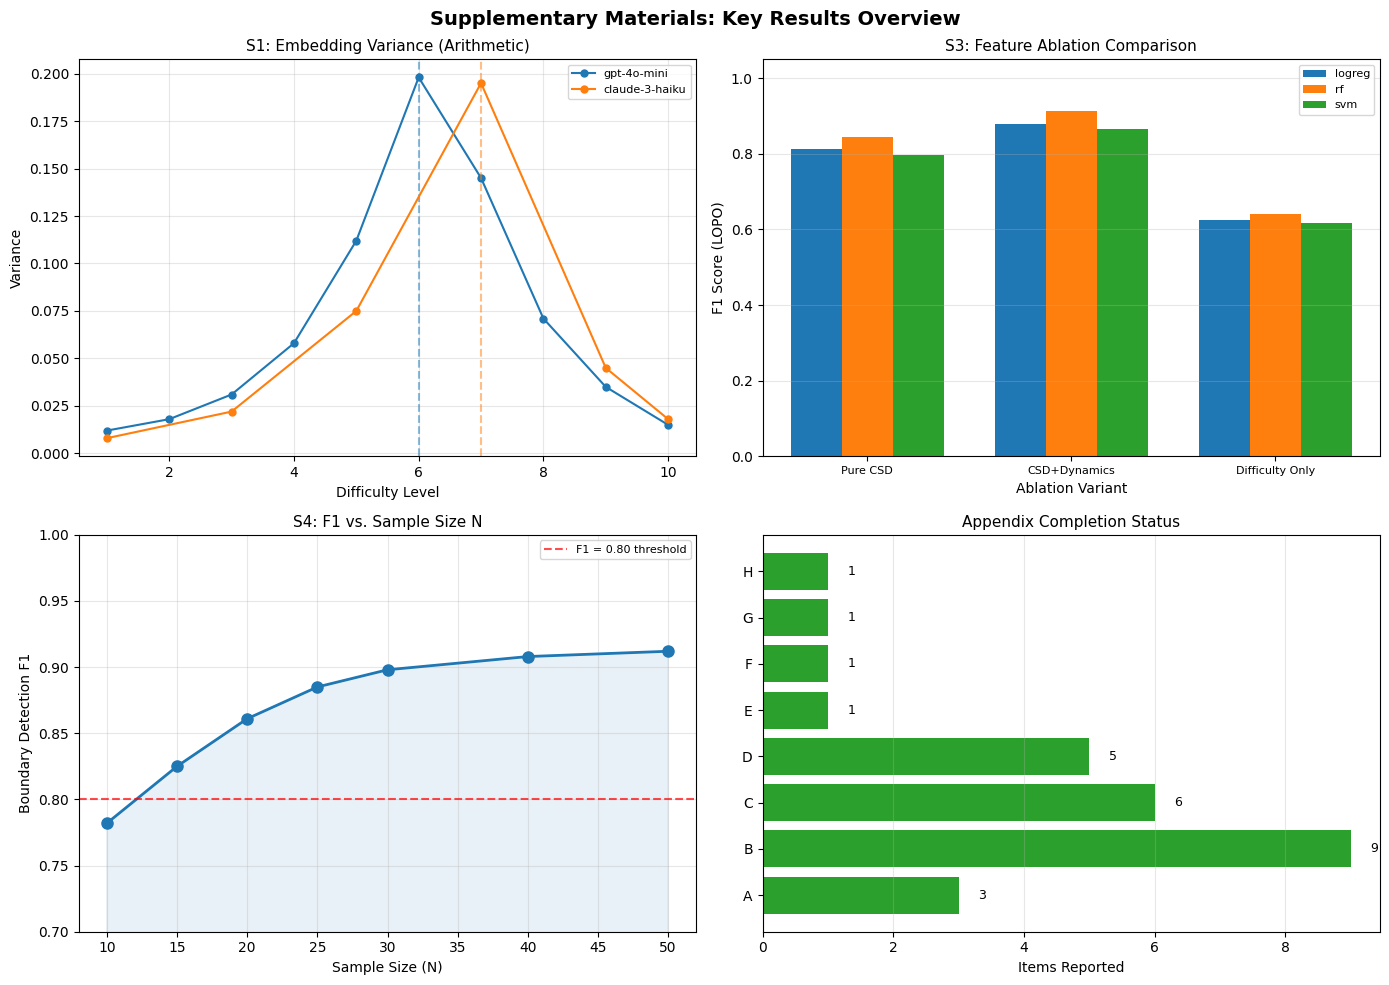

All figures generated successfully.


In [11]:
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(14 * FIG_SCALE, 10 * FIG_SCALE))

# --- Figure S1: CSD Indicator Profiles (Arithmetic) ---
ax = axes[0][0]
dep1 = data.get("dep1_arithmetic")
if dep1:
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for ds_idx, ds in enumerate(dep1.get("datasets", [])):
        examples = ds.get("examples", [])
        if not examples:
            continue
        model_name = short_model(examples[0].get("metadata_model", "unknown"))
        d_star = examples[0].get("metadata_d_star")
        diffs = sorted(set(e.get("metadata_difficulty_level", 0) for e in examples))
        vals = []
        for d in diffs:
            vs = [float(e.get("predict_csd_variance", 0)) for e in examples if e.get("metadata_difficulty_level") == d]
            vals.append(np.mean(vs) if vs else 0)
        ax.plot(diffs, vals, "-o", markersize=5, label=model_name, color=colors[ds_idx % len(colors)])
        if d_star is not None:
            ax.axvline(x=d_star, color=colors[ds_idx % len(colors)], linestyle="--", alpha=0.5)
ax.set_title("S1: Embedding Variance (Arithmetic)", fontsize=11)
ax.set_xlabel("Difficulty Level")
ax.set_ylabel("Variance")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Figure S3: Ablation Comparison Bar Chart ---
ax = axes[0][1]
ablation = data.get("eval_ablation")
if ablation:
    magg = ablation.get("metrics_agg", {})
    ablations = ["1_pure_csd", "2_csd_dynamics", "3_difficulty_only"]
    classifiers = ["logreg", "rf", "svm"]
    x = np.arange(len(ablations))
    width = 0.25
    bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for i, clf in enumerate(classifiers):
        vals = [magg.get(f"ablation_{abl}_{clf}_lopo_f1", 0) for abl in ablations]
        ax.bar(x + i * width, vals, width, label=clf, color=bar_colors[i])
    ax.set_xlabel("Ablation Variant")
    ax.set_ylabel("F1 Score (LOPO)")
    ax.set_title("S3: Feature Ablation Comparison", fontsize=11)
    ax.set_xticks(x + width)
    ax.set_xticklabels(["Pure CSD", "CSD+Dynamics", "Difficulty Only"], fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")
    ax.set_ylim(0, 1.05)

# --- Figure S4: Sample-Size Sensitivity ---
ax = axes[1][0]
if sensitivity_n and sensitivity_f1:
    ax.plot(sensitivity_n, sensitivity_f1, "-o", color="#1f77b4", linewidth=2, markersize=8)
    ax.axhline(y=0.80, color="red", linestyle="--", alpha=0.7, label="F1 = 0.80 threshold")
    ax.fill_between(sensitivity_n, sensitivity_f1, alpha=0.1, color="#1f77b4")
    ax.set_xlabel("Sample Size (N)", fontsize=10)
    ax.set_ylabel("Boundary Detection F1", fontsize=10)
    ax.set_title("S4: F1 vs. Sample Size N", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.7, 1.0)

# --- Appendix completion summary ---
ax = axes[1][1]
letters = sorted(appendix_counts.keys())
counts = [appendix_counts[l] for l in letters]
colors_bar = ["#2ca02c" if c > 0 else "#d62728" for c in counts]
ax.barh(letters, [min(c, 50) for c in counts], color=colors_bar)
ax.set_xlabel("Items Reported")
ax.set_title("Appendix Completion Status", fontsize=11)
ax.grid(alpha=0.3, axis="x")
for i, (letter, count) in enumerate(zip(letters, counts)):
    ax.text(max(counts) * 0.05 if count == 0 else count + 0.3, i, str(count), va="center", fontsize=9)

fig.suptitle("Supplementary Materials: Key Results Overview", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()
print("All figures generated successfully.")